---
title: Time inhomogeneity
---

Phase-type distributions model time-homogeneous Markov jump processes, but phasic has limited support for time-inhomogeneous processs using the two approaches described below:

In [1]:
from phasic import Graph, with_ipv
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vscodenb import set_vscode_theme, vscode_theme

sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)


## Step-wise construction

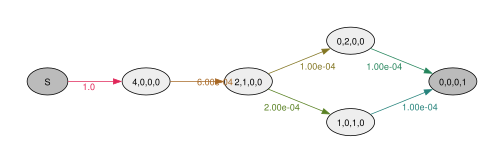

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent)
N = 10000
graph.update_weights([1/N])
graph.plot()

### PDF/CDF

Say we want to model a population bottleneck where $N$ falls to $N_{bottle}$ at time $t_{start}$ and then goes back to $N$ at time $t_{end}$. To make the approach scale to more changes, and allow more than one parameter we can define changes as a list of (start_time, parameters) tuples:

In [3]:
graph = Graph(coalescent)

N = 1
N_bottle, t_start, t_end = 0.2, 1, 1.3

param_changes = [         
                 (t_start, [1/N_bottle]), 
                 (t_end,   [1/N])
                 ]

cdf_cutoff = 0.99
cdf = []
times = []
ctx = graph.distribution_context()
graph.update_weights([1/N])

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph.update_weights(new_params)
while ctx.cdf() < cdf_cutoff:
    cdf.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()

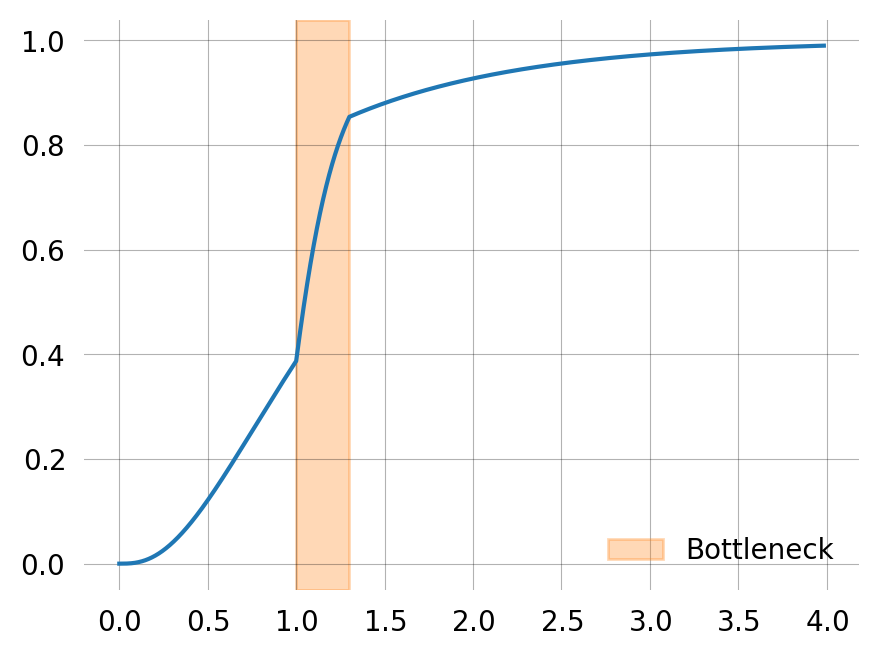

In [4]:
#| label: fig-distribution-context
plt.plot(times, cdf)
plt.axvspan(xmin=t_start, xmax=t_end, alpha=0.3, color='C1', label='Bottleneck')
plt.legend() ;


### Expectation

If we pick a time far into the future (like 1000), we can integrate under it to find the expectation. `accumulated_occupancy` computes the time spent in each state up to a time $t$, so all you have to do is sum these times. 

In [5]:
acc_occ = graph.accumulated_occupancy(1000)
acc_occ

[0.0,
 0.16666666666666563,
 0.33333333333332593,
 0.3333333333333165,
 0.666666666666633,
 0.0]

In [6]:
np.sum(acc_occ).item(), graph.expectation()

(1.499999999999941, 1.4999999999999996)

::: {.callout-tip }

Note that, unlike all other computations, and the PDF of continuous distributions are not mathematically exact. But as you can see, it is a (very good) approximation using arbitrarily small discrete steps. If the rates change dramatically, set you may have to use the granularity keyword argument to manually set granularity to a high enough value.

Keep in mind, that for time-homogeneous graphs, `expected_sojourn_time` is both exact and much faster than `accumulated_occupancy`.

:::

### Marginal expectations

We can scale by a reward, and thereby find the marginal expectation of e.g. singleton branch length accumulated by time $t$:

In [7]:
t = 2
reward_matrix = graph.states().T
np.sum(graph.accumulated_occupancy(t)*reward_matrix[0]).item()

1.8362807228049958

That lets us track how the SFS develops over time. Normalized to sum to one, we can see how singletons dominate early in the coalescence process:

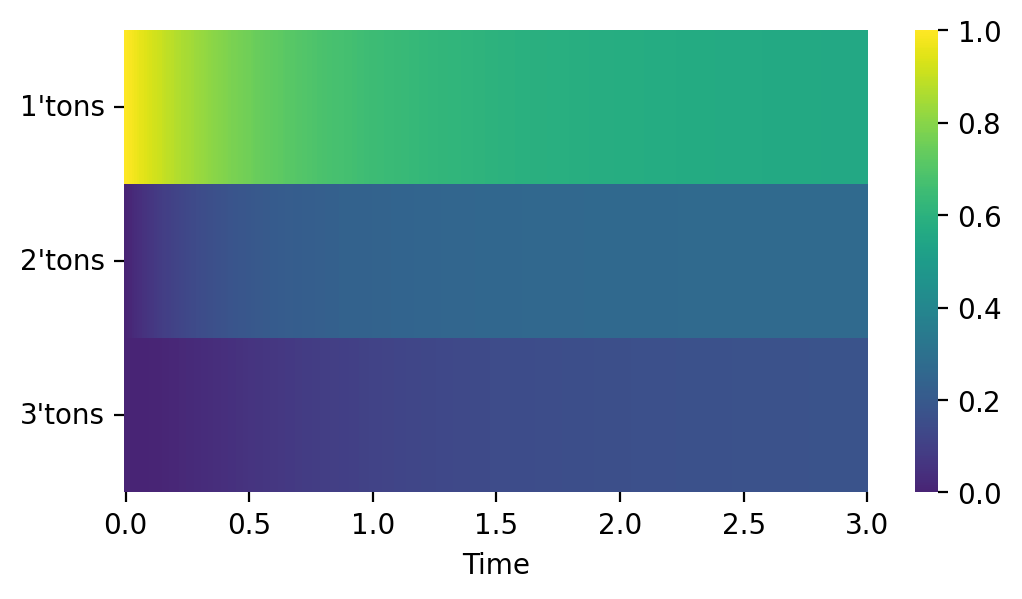

<Figure size 500x370 with 0 Axes>

In [8]:
#| label: fig-accumulated-occupancy
@np.vectorize
def brlen_accumulated(i, t):
    acc_occ = graph.accumulated_occupancy(t)*reward_matrix[i]
    return np.sum(acc_occ).item()

times = np.linspace(0, 3, 301)
tons = list(range(nr_samples-1))
X, Y = np.meshgrid(tons, times, indexing='ij')
result = brlen_accumulated(X, Y)
col_sums = result.sum(axis=0)
result = result / col_sums[np.newaxis, :]
result = pd.DataFrame(
    result, 
    columns=times, 
    index=[f"{i+1}'tons" for i in range(nr_samples-1)]
    )

with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(6,3))
    ax = sns.heatmap(result, cmap='iridis', ax=ax, 
                    xticklabels = 50 
                    )
    ax.set_xlabel('Time')
    plt.yticks(rotation=0)
    plt.show()


## Moments of epoch-wise time homogeneous phase-type distributions

In [9]:
from phasic import Graph, StateIndexer, PropertySet, Property
import numpy as np
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

def coalescent(state, indexer=None):    
    transitions = []

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])

    return transitions

nr_samples = 10

indexer = StateIndexer(
      lineages=[Property('ton', min_value=1, max_value=nr_samples)], 
  )
ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples
graph = Graph(coalescent, 
              ipv=ipv,
              indexer=indexer,
)

epoch_transitions = [0, 1, 2]
pop_sizes = [1, 5, 10]

n_epochs = len(pop_sizes)
coefs = list(zip(epoch_transitions, pop_sizes))

graph.update_weights([pop_sizes[0]])

weights = [pop_sizes[0], 1]
for i in range(1, n_epochs):    
    graph = graph.add_epoch(epoch_transitions[i])
    weights.extend([1 / pop_sizes[i], 1])
    graph.update_weights(weights)

mine = graph.moments(5)
mine
#graph.plot(size=(12, 8), wrap=False, max_nodes=300)

[8.726427931363652,
 173.42232048983158,
 5233.840746862076,
 209923.89924780512,
 10506328.51342236]

### Check that I get the same as Janek for n=10

In [10]:
janek = np.array([8.807791589074768, 177.8449395799212, 5388.12207361224, 
                   216313.46645481227, 10829024.877199283])
mine = graph.moments(5)
(mine - janek) / janek

array([-0.00923769, -0.02486784, -0.0286336 , -0.02953846, -0.02979921])

### SFS

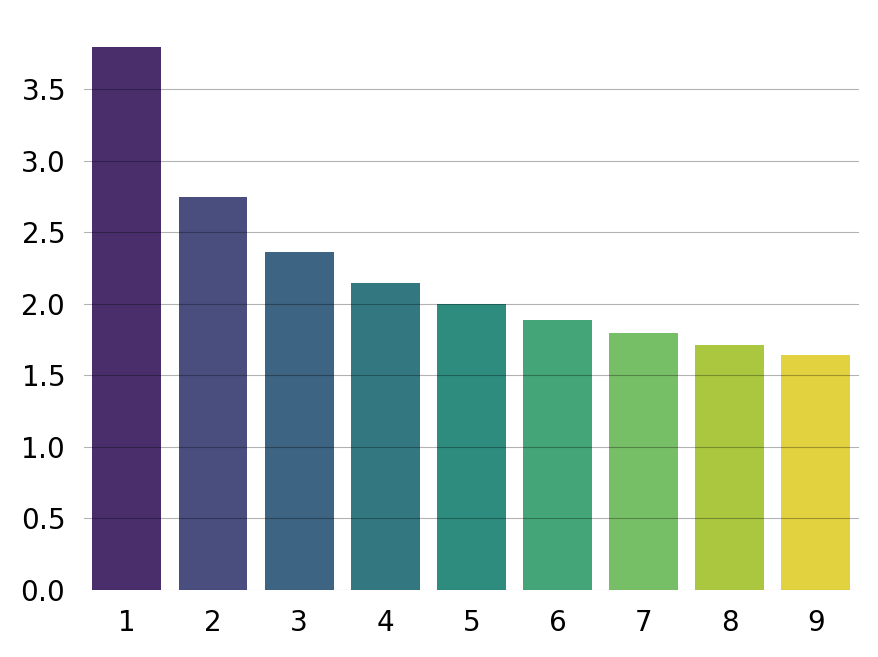

In [11]:
# Get states and remove epoch label column
state_mat = graph.states()
rewards = state_mat[:, :-1]  # Remove last column (epoch labels)

# Compute site frequency spectrum
x = np.arange(1, nr_samples)
sfs = np.zeros(nr_samples - 1)
for i in range(nr_samples - 1):
    reward_vec = rewards[:, i]
    transformed_graph = graph.reward_transform(reward_vec)
    sfs[i] = transformed_graph.moments(1)[0]

sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette='iridis', legend=False);

### Comparing to the exact results of Pool and Nielsen for pairwise coelescence time

In [12]:
def exp_coal(g, N):
    """
    Compute expected coalescence time in epoch
    N is the number of diploid invididuals
    g is the number of generations spanned by the epoch
    """
    # return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))
    return N - (g * np.exp(-g/(N))) / (1 - np.exp(-g/(N)))

def epoch(demog, h, i):
    "Recursively compute expected coalescence time across all epoches"
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
    #     return 2*N
    # return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))
        return N
    return (1-np.exp(-g/(N))) * exp_coal(g, N) + np.exp(-g/(N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """
    Compute expected coalescence time in units of 2N
    Ne is the a list/series of Ne in the epoch.
    gens is the a list/series of generation at which an each epoch begins (the last epoch lasts forever)
    h is the relative population size, 0.75 for chrX.
    """
    epochs = list()
    for i in range(len(gens)):
        if i == 0:
            epochs.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epochs.append((None, Ne[i]))    
        else:
            epochs.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epochs, h, 0)


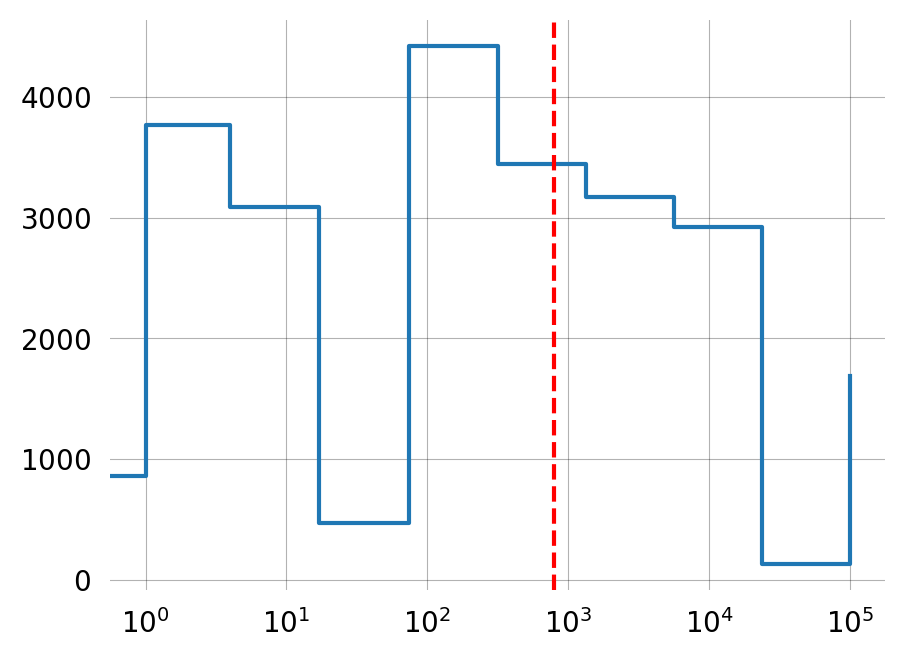

In [13]:
n = 10
sampledemog_data = pd.DataFrame(dict(years=[0]+np.logspace(0, 5, n-1, dtype=int, base=10).tolist(),
                               Ne=np.random.randint(1, 5_000, size=n),
                               population=['pop']*n
                              ))

sampledemog_data.sort_values('years', inplace=True)

gen_time = 30
exp_coal_time = pool_nielsen(gens=sampledemog_data.years / gen_time, 
                               Ne=sampledemog_data.Ne,
                               h=1)
# pool_nielsen(gens, Ne, 0.75)
plt.step(sampledemog_data.years, sampledemog_data.Ne, where='post')
plt.gca().set_xscale('log')
plt.gca().axvline(exp_coal_time, color='red', linestyle='--')
plt.show()

## Joint probability and continuous time

### Cumulative joint probability

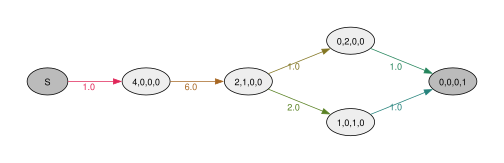

In [14]:
def coalescent(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, state[i]*(state[j]-same)/(1+same)])
    return transitions

theta = [7, 1]
reward_limit = 1
mutation_rate = 1

nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)
initial = [nr_samples]+[0]*(nr_samples-1)
graph = Graph(coalescent, ipv=initial, indexer=indexer)
graph.plot()

Create a continuous joint probability graph (only meaningful for this particular use):

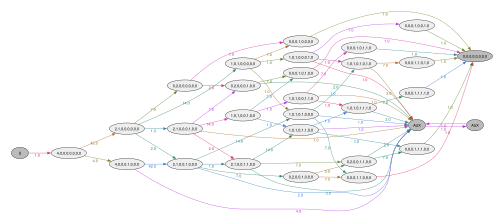

In [15]:
#| label: fig-cont-joint-prob-graph

cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 
cont_joint_graph.update_weights(theta)
cont_joint_graph.plot(nodesep=0.2)

Create a context object for computing accumulated joint probabilities across continuous time. The context wraps a a modified graph on which stop probabilities are computed.

[8, 15, 16, 18, 22, 23, 25, 26]


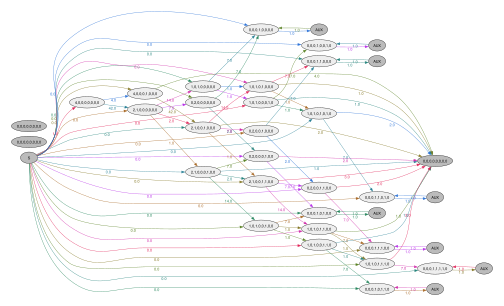

In [16]:
#| label: fig-cont-joint-prob-epoch-graph

ctx = cont_joint_graph.epoch_context()
print(ctx._t_vertex_indices)
ctx._graph.plot(nodesep=0.2)

Compute cumulative joint probabilities and their exact asymptotes for comparison (using a discrete graph):

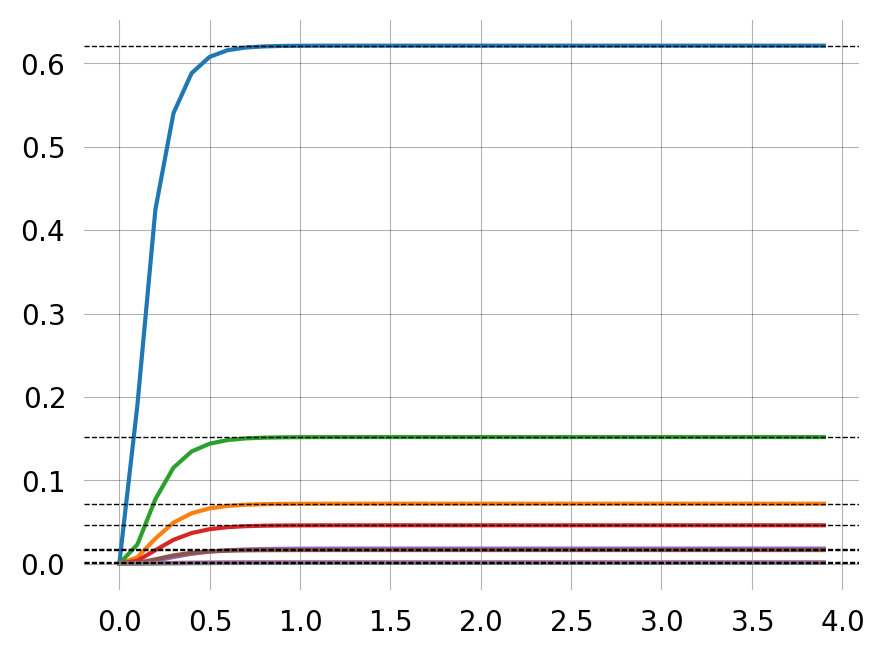

In [17]:
#| label: fig-joint-prob-over-time
t = np.arange(0, 4, 0.1)
cum_hit_probs = ctx.cumulative_probs(t)

joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=True) 
joint_graph.update_weights(theta)
df = joint_graph.joint_prob_table()
asymptotes = df.prob

fig, ax = plt.subplots()
plt.plot(t, cum_hit_probs)
[ax.axhline(a, color='k', lw=0.5, ls='--') for a in asymptotes];


### Time-inhomogeneous joint-probability

The main use of cumulative joint probability is as IPV for a subsequent epoch starting at time $t$. This way epochs can be daisy chained in effect producing a time-inhomogenous joint probability much like a time-inhomogenous uni-variate PDF can be constructed using the [`distribution-context` Graph method](time-inhomogeneous.ipynb).

In [18]:
epoch_starts = [0, 0.2, 0.5]
pop_sizes = [1, 5, 2]
cont_joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit, discrete=False) 
ctx = cont_joint_graph.epoch_context()
for t, N in zip(epoch_starts[1:], pop_sizes[:-1]):
    ctx.update_weights([1/N, mutation_rate])
    epoch_ipv = ctx.next_ipv(t)
    ctx = cont_joint_graph.epoch_context()
    ctx.update_ipv(epoch_ipv)
N = pop_sizes[-1]
ctx.update_weights([1/N, mutation_rate])
ctx.joint_probs_table()

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
8,0,0,0,0,0.032500
15,0,1,0,0,0.014725
16,1,0,0,0,0.030323
18,0,0,1,0,0.009060
22,1,0,1,0,0.014373
23,1,1,0,0,0.016132
25,0,1,1,0,0.001646
26,1,1,1,0,0.003716
